In [1]:
from wordcloud import WordCloud
print("WordCloud installed successfully!")

WordCloud installed successfully!


In [2]:
import pandas as pd
import re
from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [12]:
import os

download_path = r"C:\Users\Vedika Pingat\Downloads"

for root, dirs, files in os.walk(download_path):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

C:\Users\Vedika Pingat\Downloads\department_mapping.csv
C:\Users\Vedika Pingat\Downloads\music.csv
C:\Users\Vedika Pingat\Downloads\music_dataset_1000_songs.csv
C:\Users\Vedika Pingat\Downloads\store_mapping.csv
C:\Users\Vedika Pingat\Downloads\Titanic-Dataset.csv
C:\Users\Vedika Pingat\Downloads\archive\cybersecurity.csv


In [14]:
file_path = r"C:\Users\Vedika Pingat\Intern-Projects\Women_s_E-Commerce_Clothing_Reviews_1594_1.csv"

with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
    for i in range(5):
        print(f.readline())

;Clothing.ID;Age;Title;Review.Text;Rating;Recommended.IND;Positive.Feedback.Count;Division.Name;Department.Name;Class.Name

1;767;33;;Absolutely wonderful - silky and sexy and comfortable;4;1;0;Initmates;Intimate;Intimates

2;1080;34;;"Love this dress!  it's sooo pretty.  i happened to find it in a store, and i'm glad i did bc i never would have ordered it online bc it's petite.  i bought a petite and am 5'8"".  i love the length on me- hits just a little below the knee.  would definitely be a true midi on someone who is truly petite.";5;1;4;General;Dresses;Dresses

3;1077;60;Some major design flaws;I had such high hopes for this dress and really wanted it to work for me. i initially ordered the petite small (my usual size) but i found this to be outrageously small. so small in fact that i could not zip it up! i reordered it in petite medium, which was just ok. overall, the top half was comfortable and fit nicely, but the bottom half had a very tight under layer and several somewhat ch

In [15]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\Vedika Pingat\Intern-Projects\Women_s_E-Commerce_Clothing_Reviews_1594_1.csv",
    sep=";"
)

In [16]:
df.head()

,Unnamed: 0,Clothing.ID,Age,Title,Review.Text,Rating,Recommended.IND,Positive.Feedback.Count,Division.Name,Department.Name,Class.Name
0,1,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,2,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,3,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,4,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,5,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [17]:
df.shape

(23486, 11)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0               23486 non-null  int64 
 1   Clothing.ID              23486 non-null  int64 
 2   Age                      23486 non-null  int64 
 3   Title                    19676 non-null  object
 4   Review.Text              22641 non-null  object
 5   Rating                   23486 non-null  int64 
 6   Recommended.IND          23486 non-null  int64 
 7   Positive.Feedback.Count  23486 non-null  int64 
 8   Division.Name            23472 non-null  object
 9   Department.Name          23472 non-null  object
 10  Class.Name               23472 non-null  object
dtypes: int64(6), object(5)
memory usage: 2.0+ MB


In [19]:
df.isnull().sum()

Unnamed: 0                    0
Clothing.ID                   0
Age                           0
Title                      3810
Review.Text                 845
Rating                        0
Recommended.IND               0
Positive.Feedback.Count       0
Division.Name                14
Department.Name              14
Class.Name                   14
dtype: int64

In [20]:
reviews = df["Review.Text"]

In [21]:
reviews.head()

0    Absolutely wonderful - silky and sexy and comf...
1    Love this dress!  it's sooo pretty.  i happene...
2    I had such high hopes for this dress and reall...
3    I love, love, love this jumpsuit. it's fun, fl...
4    This shirt is very flattering to all due to th...
Name: Review.Text, dtype: object

In [22]:
reviews.isnull().sum()

np.int64(845)

In [23]:
reviews = reviews.dropna()

In [24]:
reviews.isnull().sum()

np.int64(0)

In [25]:
reviews = reviews.str.lower()

In [26]:
reviews.head()

0    absolutely wonderful - silky and sexy and comf...
1    love this dress!  it's sooo pretty.  i happene...
2    i had such high hopes for this dress and reall...
3    i love, love, love this jumpsuit. it's fun, fl...
4    this shirt is very flattering to all due to th...
Name: Review.Text, dtype: object

In [27]:
reviews = reviews.str.replace(r"[^\w\s]", "", regex=True)

In [28]:
reviews.head()

0    absolutely wonderful  silky and sexy and comfo...
1    love this dress  its sooo pretty  i happened t...
2    i had such high hopes for this dress and reall...
3    i love love love this jumpsuit its fun flirty ...
4    this shirt is very flattering to all due to th...
Name: Review.Text, dtype: object

In [29]:
reviews = reviews.str.replace(r"\s+", " ", regex=True)
reviews = reviews.str.strip()

In [30]:
reviews.head()

0    absolutely wonderful silky and sexy and comfor...
1    love this dress its sooo pretty i happened to ...
2    i had such high hopes for this dress and reall...
3    i love love love this jumpsuit its fun flirty ...
4    this shirt is very flattering to all due to th...
Name: Review.Text, dtype: object

In [31]:
all_text = " ".join(reviews)

In [32]:
print(all_text[:500])

absolutely wonderful silky and sexy and comfortable love this dress its sooo pretty i happened to find it in a store and im glad i did bc i never would have ordered it online bc its petite i bought a petite and am 58 i love the length on me hits just a little below the knee would definitely be a true midi on someone who is truly petite i had such high hopes for this dress and really wanted it to work for me i initially ordered the petite small my usual size but i found this to be outrageously sm


In [33]:
words = all_text.split()

In [34]:
print(words[:20])

['absolutely', 'wonderful', 'silky', 'and', 'sexy', 'and', 'comfortable', 'love', 'this', 'dress', 'its', 'sooo', 'pretty', 'i', 'happened', 'to', 'find', 'it', 'in', 'a']


In [35]:
from collections import Counter

word_freq = Counter(words)

In [36]:
len(word_freq)

19385

In [37]:
top_words = word_freq.most_common(20)
top_words

[('the', 75904),
 ('i', 58899),
 ('and', 48831),
 ('a', 42798),
 ('it', 42530),
 ('is', 30619),
 ('this', 25680),
 ('to', 24440),
 ('in', 20571),
 ('but', 16392),
 ('on', 15181),
 ('for', 13986),
 ('of', 13421),
 ('with', 12780),
 ('was', 12216),
 ('so', 11899),
 ('my', 11015),
 ('dress', 10460),
 ('not', 9688),
 ('that', 9542)]

In [38]:
from collections import Counter

stop_words = {
    'the','i','and','a','it','is','this','to','in','but','on',
    'for','of','with','was','so','my','not','that','at','as',
    'are','be','have','had','you','they','we','an','or','if',
    'its','im','me','them','she','he','his','her'
}

filtered_words = [word for word in words if word not in stop_words]

In [39]:
word_freq_filtered = Counter(filtered_words)

top_words_filtered = word_freq_filtered.most_common(20)

top_words_filtered

[('dress', 10460),
 ('love', 8916),
 ('size', 8687),
 ('very', 8169),
 ('top', 7323),
 ('fit', 7238),
 ('like', 6992),
 ('wear', 6414),
 ('great', 6076),
 ('too', 6009),
 ('am', 5741),
 ('just', 5572),
 ('would', 5010),
 ('fabric', 4755),
 ('up', 4729),
 ('color', 4557),
 ('small', 4539),
 ('look', 4014),
 ('really', 3921),
 ('more', 3921)]

In [40]:
top_words_df = pd.DataFrame(
    top_words_filtered,
    columns=["Word", "Frequency"]
)

top_words_df

,Word,Frequency
0,dress,10460
1,love,8916
2,size,8687
3,very,8169
4,top,7323
5,fit,7238
6,like,6992
7,wear,6414
8,great,6076
9,too,6009


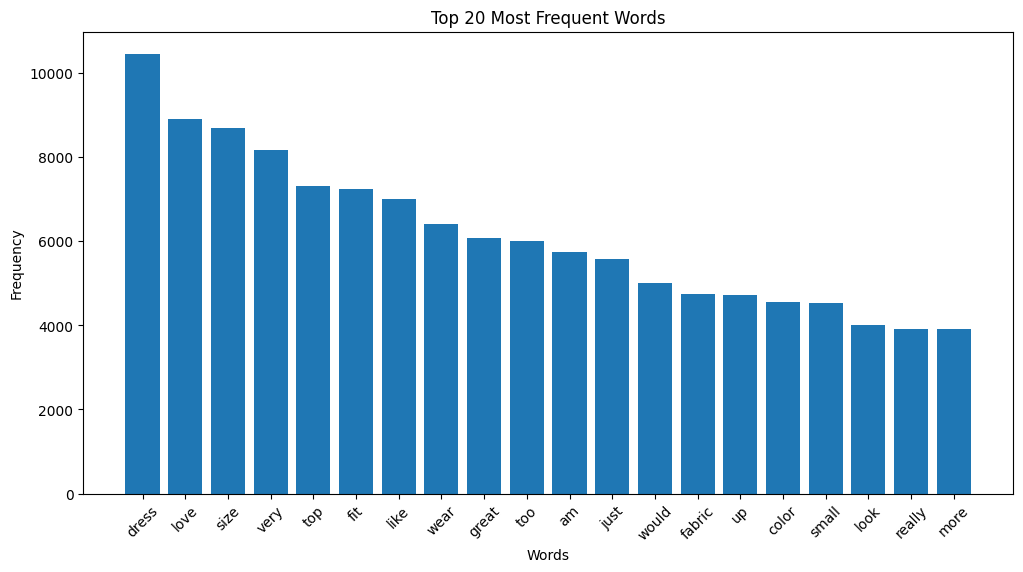

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(
    top_words_df["Word"],
    top_words_df["Frequency"]
)

plt.xticks(rotation=45)
plt.title("Top 20 Most Frequent Words")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.show()

In [44]:
from wordcloud import WordCloud

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="pink"
).generate(" ".join(filtered_words))

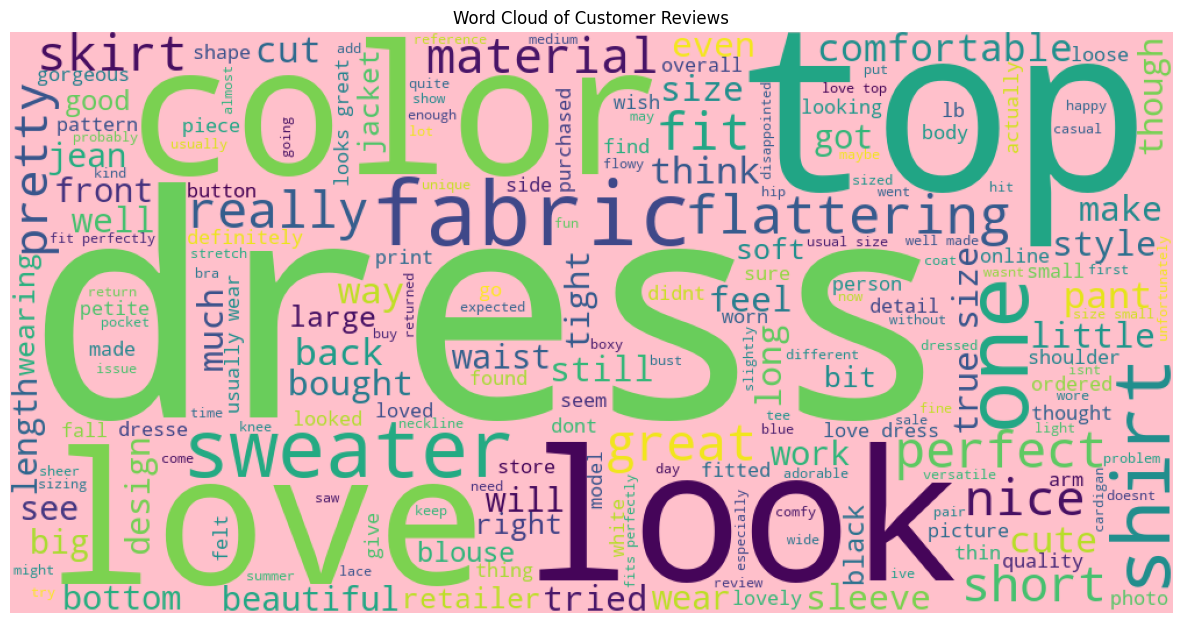

In [47]:
plt.figure(figsize=(15,8))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Word Cloud of Customer Reviews")

plt.show()

In [ ]:
#The customer reviews were cleaned by removing missing values, converting text to lowercase, removing
#punctuation, and eliminating extra spaces. Word frequency analysis revealed that words such as "dress",
#"love", "size", "fit", and "fabric" appeared most frequently. The word cloud further highlighted customer
#focus on clothing fit, comfort, fabric quality, and overall satisfaction. These insights indicate that sizing, fit,
#and product quality are the primary factors influencing customer reviews.